<a href="https://colab.research.google.com/github/Anchor-head/ScienceGenreClassification/blob/main/SetFit-SciBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installations and basic imports

In [ ]:
!unzip data.zip -d "/content/drive/MyDrive/"

Archive:  data.zip
   creating: data/
  inflating: data/dataset1.parquet   
  inflating: data/dataset1.xlsx      
  inflating: data/est_split2.xlsx    
  inflating: data/testfold1.parquet  
  inflating: data/testfold2.parquet  
  inflating: data/testfold3.parquet  
  inflating: data/testfold4.parquet  
  inflating: data/test_split.parquet  
  inflating: data/test_split2.parquet  
  inflating: data/test_split3.parquet  
  inflating: data/test_split4.parquet  
  inflating: data/trainfold1.parquet  
  inflating: data/trainfold2.parquet  
  inflating: data/trainfold3.parquet  
  inflating: data/trainfold4.parquet  
  inflating: data/train_split.parquet  
  inflating: data/train_split2.parquet  
  inflating: data/train_split3.parquet  
  inflating: data/train_split4.parquet  
  inflating: data/X_test_contents.csv  


In [4]:
!pip install "datasets>=2.15.0,<3.0.0"
!pip install setfit
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 15.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
from typing import Literal

In [6]:
from setfit import SetFitModel

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Train SetFit

In [ ]:
from datasets import load_dataset, Dataset
from setfit import Trainer, TrainingArguments

## Simply validated

### First model
Model: scincl

Train-test split: 1

Batch size: 16

Epochs: 4

Accuracy: 0.48905

In [ ]:
df = load_dataset("parquet", data_files={'train': "train_split.parquet", 'test': "test_split.parquet"})

# Load a dataset from the Hugging Face Hub
'''
train_df = load_dataset("parquet", data_files="train_split.parquet")
train_text = train_df["train"]["fullText"]
train_label = train_df["train"]["Document_subtype"]
train_data = Dataset.from_dict({ "fullText" : train_text, "Document_subtype" : train_label })

test_df = load_dataset("parquet", data_files="test_split.parquet")
test_text = test_df["train"]["fullText"]
test_label = test_df["train"]["Document_subtype"]
test_data = Dataset.from_dict({ "fullText" : test_text, "Document_subtype" : test_label })

# Simulate the few-shot regime by sampling 8 examples per class
train_dataset = sample_dataset(dataset["train"], label_column="Document_subtype")
eval_dataset = dataset["validation"].select(range(100))
test_dataset = dataset["validation"].select(range(100, len(dataset["validation"])))
'''

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "malteos/scincl",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)

'''
# Push model to the Hub
trainer.push_to_hub("tomaarsen/setfit-paraphrase-mpnet-base-v2-sst2")

# Download from Hub
model = SetFitModel.from_pretrained("tomaarsen/setfit-paraphrase-mpnet-base-v2-sst2")
# Run inference
preds = model.predict(["i loved the spiderman movie!", "pineapple on pizza is the worst 🤮"])
print(preds)
# ["positive", "negative"]
'''

### Second model
Model: scincl

Train-test split: 1

Batch size: 16

Epochs: 5

Accuracy: 0.49635

In [ ]:
df = load_dataset("parquet", data_files={'train': "train_split.parquet", 'test': "test_split.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "malteos/scincl",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)

model.save_pretrained("./model2")

### Third model
Model: jordyvl

Train-test split: 1

Batch size: 16

Epochs: 5

Accuracy: 0.5401459854014599

In [ ]:
df = load_dataset("parquet", data_files={'train': "train_split.parquet", 'test': "test_split.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "jordyvl/scibert_scivocab_uncased_sentence_transformer",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)

model.save_pretrained("./model3")

### Fourth model
Model: jordyvl

Train-test split: 2

Batch size: 16

Epochs: 1

Accuracy: 0.5876

In [ ]:
df = load_dataset("parquet", data_files={'train': "train_split2.parquet", 'test': "test_split2.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "jordyvl/scibert_scivocab_uncased_sentence_transformer",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)

model.save_pretrained("./model4")

### Fifth model
Model: jordyvl

Train-test split: 3

Batch size: 16

Epochs: 1

Accuracy: 0.5593

In [ ]:
df = load_dataset("parquet", data_files={'train': "train_split3.parquet", 'test': "test_split3.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained(
    "jordyvl/scibert_scivocab_uncased_sentence_transformer",
    labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"],
)

args = TrainingArguments(
    batch_size=16,
    num_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)

model.save_pretrained("./model5")

### Sixth model

Model: jordyvl

Train-test split: 2

Batch size: 16

Epochs: 5

Accuracy: 0.56 (epoch 2), 0.597-0.6392 (epoch 5), 0.5464 (epoch 10)




In [ ]:
df = load_dataset("parquet", data_files={'train': "train_split2.parquet", 'test': "test_split2.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained("jordyvl/scibert_scivocab_uncased_sentence_transformer", labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"])

args = TrainingArguments(
    batch_size=16,
    num_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)

model.save_pretrained("./model6")

In [ ]:
df = load_dataset("parquet", data_files={'train': "train_split2.parquet", 'test': "test_split2.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained("./model6")

args = TrainingArguments(
    batch_size=16,
    num_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)

model.save_pretrained("./model6-10")

NameError: name 'df' is not defined

## Cross-validated

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold

### Seventh model

Model: jordyvl

RepeatedStratifiedKFold: 2x2

Batch size: 16

Epochs: 5

Accuracy:
Fold 1: 0.54
Fold 2:
Fold 3: 0.6
Fold 4: 0.54

In [ ]:
df = load_dataset("parquet", data_files={'train': "trainfold1.parquet", 'test': "testfold1.parquet"})

# Load a SetFit model from Hub
model = SetFitModel.from_pretrained("jordyvl/scibert_scivocab_uncased_sentence_transformer", labels=["Retraction", "Correction", "Editorial", "Policy, Science and Society", "News Journalism", "Research Document", "Letter", "Book Review", "Societies and People", "Miscellanea"])

args = TrainingArguments(
    batch_size=16,
    num_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=df['train'],
    eval_dataset=df['test'],
    metric="accuracy",
    column_mapping={"fullText": "text", "Document_subtype": "label"}  # Map dataset columns to text/label expected by trainer
)

# Train and evaluate
trainer.train()
metrics = trainer.evaluate(df['test'])
print(metrics)

model.save_pretrained("./model7")

# Train head

In [7]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

In [8]:
# Initialize body
model = SetFitModel.from_pretrained("./model6")

In [9]:
# Initialize head


head = RandomForestClassifier()

'''
# Accuracy: 0.7216494845360825, Accuracy: 0.7010309278350515
head = CatBoostClassifier(iterations=200, one_hot_max_size=500)


### Accuracy: 0.7010309278350515, 0.711340206185567
### metadata = {'categorical':['Jstor_docSubType','Jstor_docType','Science_section_corrected'],
###             'numerical':['Jstor_pageCount','Jstor_wordCount']}
### DOES NOT USE Jstor_tdmCategory (and using it doesn't improve it)
head = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.9,
    colsample_bytree=0.5,
    gamma=0,
    objective='multi:softmax',
    num_class=10,
)


### Accuracy: 0.7010, 0.7113
### metadata = {'categorical':['Jstor_docSubType','Jstor_docType','Science_section_corrected'],
###             'numerical':['Jstor_pageCount','Jstor_wordCount', 'Jstor_pageStart']}
### DOES NOT USE Jstor_tdmCategory
head = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=0,
    objective='multi:softmax',
    num_class=10,
)

### Accuracy: 0.6804
### metadata = {'categorical':['Jstor_docSubType','Jstor_docType','Science_section_corrected'],
###             'numerical':['Jstor_pageCount','Jstor_wordCount']}
### DOES NOT USE Jstor_tdmCategory
head = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=1,
    objective='multi:softmax',
    num_class=10,
)


head = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=1,
    objective='multi:softmax',  # Set for multi-class classification
    num_class=10  # Number of classes
)

head = XGBClassifier(
    colsample_bytree=0.7,
    gamma=1,
    learning_rate=0.01,
    max_depth=3,
    n_estimators=200,
    scale_pos_weight=1,
    subsample=0.5
    objective='multi:softmax',  # Set for multi-class classification
    num_class=10  # Number of classes
)
'''
# head = LogisticRegression(max_iter = 2000)
# head = MLPClassifier(activation="tanh", hidden_layer_sizes = (10,), max_iter = 1000)

"\n# Accuracy: 0.7216494845360825, Accuracy: 0.7010309278350515\nhead = CatBoostClassifier(iterations=200, one_hot_max_size=500)\n\n\n### Accuracy: 0.7010309278350515, 0.711340206185567\n### metadata = {'categorical':['Jstor_docSubType','Jstor_docType','Science_section_corrected'],\n###             'numerical':['Jstor_pageCount','Jstor_wordCount']}\n### DOES NOT USE Jstor_tdmCategory (and using it doesn't improve it)\nhead = XGBClassifier(\n    n_estimators=200,\n    max_depth=4,\n    learning_rate=0.01,\n    subsample=0.9,\n    colsample_bytree=0.5,\n    gamma=0,\n    objective='multi:softmax',\n    num_class=10,\n)\n\n\n### Accuracy: 0.7010, 0.7113\n### metadata = {'categorical':['Jstor_docSubType','Jstor_docType','Science_section_corrected'],\n###             'numerical':['Jstor_pageCount','Jstor_wordCount', 'Jstor_pageStart']}\n### DOES NOT USE Jstor_tdmCategory\nhead = XGBClassifier(\n    n_estimators=300,\n    max_depth=4,\n    learning_rate=0.01,\n    subsample=0.8,\n    colsamp

## With single split

In [10]:
datapath = 'data/dataset1.parquet'
trainpath = 'data/train_split2.parquet'
testpath = 'data/test_split2.parquet'
trainpath2 = 'data/train_split5.parquet'
testpath2 = 'data/test_split5.parquet'

data = pd.read_parquet(datapath)
df = {}
df['train'] = pd.read_parquet(trainpath)
df['test'] = pd.read_parquet(testpath)
df['train2'] = pd.read_parquet(trainpath2)
df['test2'] = pd.read_parquet(testpath2)
metadata = {'categorical':['Jstor_docSubType','Jstor_docType','Science_section_corrected'],
            'numerical':['Jstor_pageCount','Jstor_wordCount']}

### Optional preprocessing

In [ ]:
df['train']['Jstor_tdmCategory'] = df['train']['Jstor_tdmCategory'].apply(lambda x: [a.strip(" '[]") for a in x.split(',')] if isinstance(x, str) else x)
df['test']['Jstor_tdmCategory'] = df['test']['Jstor_tdmCategory'].apply(lambda x: [a.strip(" '[]") for a in x.split(',')] if isinstance(x, str) else x)
data['Jstor_tdmCategory'] = data['Jstor_tdmCategory'].apply(lambda x: [a.strip(" '[]") for a in x.split(',')] if isinstance(x, str) else x)

tdmCategories = []
mycol = data['Jstor_tdmCategory']
for i in range(len(mycol)):
  if mycol[i]:
    for item in mycol[i]:
      if item not in tdmCategories:
        tdmCategories.append(item)

print(len(tdmCategories), tdmCategories)

# Create dummy variables for tdmCategories
for category in tdmCategories:
    df['train'][category] = 0
    df['test'][category] = 0


# Map the values in Jstor_tdmCategory to the dummy variables
for split in ['train', 'test']:
    for index, row in df[split].iterrows():
        if isinstance(row['Jstor_tdmCategory'], list):
            for category in row['Jstor_tdmCategory']:
                if category in tdmCategories:
                    df[split].at[index, category] = 1

45 ['Biological sciences - Biology', 'Philosophy - Applied philosophy', 'Arts - Performing arts', 'Physical sciences - Earth sciences', 'Health sciences - Health and wellness', 'Arts - Applied arts', 'Physical sciences - Physics', 'Physical sciences - Astronomy', 'Political science - Military science', 'Physical sciences - Chemistry', 'Education - Formal education', 'Social sciences - Communications', 'Biological sciences - Agriculture', 'Health sciences - Medical sciences', 'Health sciences - Medical treatment', 'Biological sciences - Biochemistry', 'Business - Business administration', 'Political science - Government', 'Biological sciences - Paleontology', 'Education - Specialized education', 'Biological sciences - Ecology', 'Information science - Information resources', 'Business - Industry', 'Law - Civil law', 'Economics - Economic disciplines', 'Applied sciences - Systems science', 'Information science - Informetrics', 'Law - Computer law', 'Law - Judicial system', 'Political scie

In [ ]:
df['train']['model_prediction'] = pd.Series(model.predict(df['train']['fullText']))
df['test']['model_prediction'] = pd.Series(model.predict(df['test']['fullText']))
data['model_prediction'] = pd.Series(model.predict(data['fullText']))

In [ ]:
def safe_int_conversion(value):
    try:
        return int(value)
    except ValueError:
        return 0

data['Jstor_pageStart'] = data['Jstor_pageStart'].apply(safe_int_conversion)
df['train']['Jstor_pageStart'] = df['train']['Jstor_pageStart'].apply(safe_int_conversion)
df['test']['Jstor_pageStart'] = df['test']['Jstor_pageStart'].apply(safe_int_conversion)
df['train2']['Jstor_pageStart'] = df['train2']['Jstor_pageStart'].apply(safe_int_conversion)
df['test2']['Jstor_pageStart'] = df['test2']['Jstor_pageStart'].apply(safe_int_conversion)

In [ ]:
# Normalize numerical variables
for i in metadata['numerical']:
    df['train'][i]=(df['train'][i]-data[i].min())/(data[i].max()-data[i].min())
    df['test'][i]=(df['test'][i]-data[i].min())/(data[i].max()-data[i].min())

### Preprocess, train and test

In [ ]:
# Process categorical variables into one-hot encodings
categories = []
for i in metadata['categorical']:
    categories.append(data[i].dropna().unique())

encoder = OneHotEncoder(categories=categories, sparse_output=False, handle_unknown='ignore')
encoder.fit(data[metadata['categorical']])
# encoder = OrdinalEncoder(categories=categories, handle_unknown='use_encoded_value', unknown_value=np.nan)
ohe = {}
ohe['train'] = encoder.transform(df['train'][metadata['categorical']])
ohe['test'] = encoder.transform(df['test'][metadata['categorical']])
ohe['train2'] = encoder.transform(df['train2'][metadata['categorical']])
ohe['test2'] = encoder.transform(df['test2'][metadata['categorical']])

# ohe is a matrix of all one-hot variables
# each element represents a document's ohe over all categoricals



# Function to create feature vector
def create_mdvector(split: Literal['train', 'test', 'train2', 'test2'], row):

    # initialize vector of numerical variables
    numsvector = np.empty(len(metadata['numerical']))

    # build numerical vector
    for i in range(len(numsvector)):
        numsvector[i]=df[split][metadata['numerical'][i]][row]


    '''
    catsvector = np.empty(len(tdmCategories))

    for i in range(len(numsvector)):
        catsvector[i]=df[split][tdmCategories[i]][0]
    '''
    # concatenate numerical vector and categorical one-hot vector for full metadata vector
    mdvector = np.append(numsvector,ohe[split][row])
   # mdvector = np.append(mdvector,catsvector)
    return mdvector


# Function to turn input data into vector
def vectorize(split: Literal['train', 'test', 'train2', 'test2'], row):

    # Create embedding
    encoding = model.encode(df[split]['fullText'][row])
    #encoding = model.predict(df[split]['fullText'][row])

    # Create feature vector
    mdvector = create_mdvector(split,row)

    # Concatenate the embedding and feature vector
    final_vector = np.append(encoding,mdvector)
    return final_vector



# Prepare the data
X_train = pd.DataFrame([vectorize('train', i) for i in range(df['train'].shape[0])])  # Create feature vectors for all rows
X_test = pd.DataFrame([vectorize('test', i) for i in range(df['test'].shape[0])])  # Create feature vectors for all rows
X_train2 = pd.DataFrame([vectorize('train2', i) for i in range(df['train2'].shape[0])])  # Create feature vectors for all rows
X_test2 = pd.DataFrame([vectorize('test2', i) for i in range(df['test2'].shape[0])])  # Create feature vectors for all rows

# Extract and encode target variable for XGBoost
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df['train']['Document_subtype'])
y_test = label_encoder.transform(df['test']['Document_subtype'])
y_train2 = label_encoder.transform(df['train2']['Document_subtype'])
y_test2 = label_encoder.transform(df['test2']['Document_subtype'])



head.fit(X_train, y_train)

# Make predictions
predictions = head.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy}')





head.fit(X_train2, y_train2)

# Make predictions
predictions = head.predict(X_test2)

# Evaluate the model
accuracy = accuracy_score(y_test2, predictions)
print(f'Accuracy: {accuracy}')


In [63]:
# Prepare the data
all_features = metadata['numerical']+metadata['categorical']
X_train = df['train'][all_features]
X_test = df['test'][all_features]
X_train2 = df['train2'][all_features]
X_test2 = df['test2'][all_features]

# Fill missing values in categorical columns with a placeholder string
for col in metadata['categorical']:
    X_train[col] = X_train[col].fillna('')
    X_test[col] = X_test[col].fillna('')
    X_train2[col] = X_train2[col].fillna('')
    X_test2[col] = X_test2[col].fillna('')


# Extract and encode target variable for XGBoost
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df['train']['Document_subtype'])
y_test = label_encoder.transform(df['test']['Document_subtype'])
y_train2 = label_encoder.transform(df['train2']['Document_subtype'])
y_test2 = label_encoder.transform(df['test2']['Document_subtype'])



head.fit(X_train, y_train, cat_features=metadata['categorical'])

# Make predictions
predictions = head.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy}')





head.fit(X_train2, y_train2, cat_features=metadata['categorical'])

# Make predictions
predictions = head.predict(X_test2)

# Evaluate the model
accuracy = accuracy_score(y_test2, predictions)
print(f'Accuracy: {accuracy}')

/tmp/ipython-input-792561358.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].fillna('')
/tmp/ipython-input-792561358.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].fillna('')
/tmp/ipython-input-792561358.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

Learning rate set to 0.274541
0:	learn: 2.0027661	total: 1.38ms	remaining: 275ms
1:	learn: 1.8059710	total: 3.27ms	remaining: 324ms
2:	learn: 1.6786020	total: 4.88ms	remaining: 320ms
3:	learn: 1.5752121	total: 6.34ms	remaining: 311ms
4:	learn: 1.4808056	total: 7.79ms	remaining: 304ms
5:	learn: 1.4192881	total: 9.28ms	remaining: 300ms
6:	learn: 1.3524702	total: 10.7ms	remaining: 295ms
7:	learn: 1.2971534	total: 12ms	remaining: 289ms
8:	learn: 1.2477651	total: 13.4ms	remaining: 284ms
9:	learn: 1.2033413	total: 14.7ms	remaining: 279ms
10:	learn: 1.1526051	total: 16ms	remaining: 275ms
11:	learn: 1.1218200	total: 17.5ms	remaining: 274ms
12:	learn: 1.0907346	total: 19ms	remaining: 273ms
13:	learn: 1.0502352	total: 20.3ms	remaining: 270ms
14:	learn: 1.0192994	total: 21.6ms	remaining: 266ms
15:	learn: 0.9906401	total: 23ms	remaining: 265ms
16:	learn: 0.9669803	total: 24.5ms	remaining: 264ms
17:	learn: 0.9439974	total: 25.9ms	remaining: 262ms
18:	learn: 0.9117109	total: 27.3ms	remaining: 260ms


## With cross-validation

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold

In [ ]:
data = pd.read_parquet('data/dataset1.parquet')
metadata = {'categorical':['Jstor_docSubType','Jstor_docType','Science_section_corrected'],
            'numerical':['Jstor_pageCount','Jstor_wordCount']}

In [ ]:
data['Jstor_tdmCategory'] = data['Jstor_tdmCategory'].apply(lambda x: [a.strip(" '[]") for a in x.split(',')] if isinstance(x, str) else x)

tdmCategories = []
mycol = data['Jstor_tdmCategory']
for i in range(len(mycol)):
  if mycol[i]:
    for item in mycol[i]:
      if item not in tdmCategories:
        tdmCategories.append(item)

print(len(tdmCategories))
print(tdmCategories)

['Biological sciences - Biology', 'Philosophy - Applied philosophy', 'Arts - Performing arts', 'Physical sciences - Earth sciences', 'Health sciences - Health and wellness', 'Arts - Applied arts', 'Physical sciences - Physics', 'Physical sciences - Astronomy', 'Political science - Military science', 'Physical sciences - Chemistry', 'Education - Formal education', 'Social sciences - Communications', 'Biological sciences - Agriculture', 'Health sciences - Medical sciences', 'Health sciences - Medical treatment', 'Biological sciences - Biochemistry', 'Business - Business administration', 'Political science - Government', 'Biological sciences - Paleontology', 'Education - Specialized education', 'Biological sciences - Ecology', 'Information science - Information resources', 'Business - Industry', 'Law - Civil law', 'Economics - Economic disciplines', 'Applied sciences - Systems science', 'Information science - Informetrics', 'Law - Computer law', 'Law - Judicial system', 'Political science

In [ ]:
# Create dummy variables for tdmCategories
for category in tdmCategories:
    data[category] = 0


# Map the values in Jstor_tdmCategory to the dummy variables
for index, row in data.iterrows():
    if isinstance(row['Jstor_tdmCategory'], list):
        for category in row['Jstor_tdmCategory']:
            if category in tdmCategories:
                data.at[index, category] = 1

In [ ]:
# Normalize numerical variables
for i in metadata['numerical']:
    data[i]=(data[i]-data[i].min())/(data[i].max()-data[i].min())

In [ ]:
# Process categorical variables into one-hot encodings
categories = []
for i in metadata['categorical']:
    categories.append(df[i].dropna().unique())

encoder = OneHotEncoder(categories=categories, sparse_output=False, handle_unknown='ignore')
ohe = encoder.fit_transform(data[metadata['categorical']])
# ohe is a matrix of all one-hot variables
# each element represents a document's ohe over all categoricals


# Function to create metadata feature vector
def create_mdvector(dataset, row):

    # initialize vector of numerical variables
    numsvector = np.empty((num_nums := len(metadata['numerical'])))

    # build numerical vector
    for i in range(num_nums):
        numsvector[i]=dataset[metadata['numerical'][i]][row]


    catsvector = np.empty(len(tdmCategories))

    for i in range(len(numsvector)):
        catsvector[i]=dataset[tdmCategories[i]][0]

    # concatenate numerical vector and categorical one-hot vector for full metadata vector
    mdvector = np.append(numsvector,ohe[row])
    mdvector = np.append(mdvector,catsvector)
    return mdvector


# Function to turn input data into vector
def vectorize(dataset, row):

    # Create embedding
    encoding = model.encode(dataset['fullText'][row])

    # Create feature vector
    mdvector = create_mdvector(dataset,row)

    # Concatenate the embedding and feature vector
    final_vector = np.append(encoding,mdvector)
    return final_vector




X = pd.DataFrame([create_mdvector(data, i) for i in range(data.shape[0])])  # Create feature vectors for all rows
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Document_subtype'])

labels = df['Document_subtype']




# Set up Stratified K-Fold Cross-Validation
skf = RepeatedStratifiedKFold(n_splits=2, n_repeats=2, random_state=42)

for train_index, test_index in skf.split(np.zeros(len(labels)), labels):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    head.fit(X_train, y_train)

    # Make predictions
    predictions = head.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, predictions)
    print(f'Accuracy: {accuracy}')

Accuracy: 0.65
Accuracy: 0.61
Accuracy: 0.64
Accuracy: 0.65


## Grid search

In [9]:
from sklearn.model_selection import GridSearchCV

### Import and split data

In [10]:
data = pd.read_parquet('data/mydataset.parquet')

metadata = {'categorical':['Jstor_docSubType','Jstor_docType','Science_section_corrected'],
            'numerical':['Jstor_pageCount','Jstor_wordCount']}

In [11]:
########## Define splits ##############

splits = []

# Find the index of the Document_subtype column
subtype_col = 'Document_subtype'

# Group line indices by Document_subtype
subtype_to_indices = defaultdict(list)
for i, subtype in enumerate(data[subtype_col]):
    subtype_to_indices[subtype].append(i)

# Define the required counts for each Document_subtype
required_counts = {
    'Book Review': 8,
    'Policy, Science and Society': 9,
    'Editorial': 3,
    'News Journalism': 7,
    'Societies and People': 13,
    'Correction': 3,
    'Retraction': 1,
    'Miscellanea': 8,
    'Research Document': 28,
    'Letter': 23,
}

for i in [42, 69]:
    np.random.seed(i)

    train_indices = []
    for subtype, n in required_counts.items():
        indices = subtype_to_indices.get(subtype, [])
        np.random.shuffle(indices)
        train_indices.extend(indices[:n])

    # Create train and test splits
    all_indices = set(range(len(data)))
    train_indices_set = set(train_indices)
    test_indices = list(all_indices - train_indices_set)
    splits.append((train_indices, test_indices))

### Optional preprocessing

In [ ]:
data['Jstor_tdmCategory'] = data['Jstor_tdmCategory'].apply(lambda x: [a.strip(" '[]") for a in x.split(',')] if isinstance(x, str) else x)

tdmCategories = []
mycol = data['Jstor_tdmCategory']
for i in range(len(mycol)):
  if mycol[i]:
    for item in mycol[i]:
      if item not in tdmCategories:
        tdmCategories.append(item)

print(len(tdmCategories))
print(tdmCategories)

45
['Biological sciences - Biology', 'Philosophy - Applied philosophy', 'Arts - Performing arts', 'Physical sciences - Earth sciences', 'Health sciences - Health and wellness', 'Arts - Applied arts', 'Physical sciences - Physics', 'Physical sciences - Astronomy', 'Political science - Military science', 'Physical sciences - Chemistry', 'Education - Formal education', 'Social sciences - Communications', 'Biological sciences - Agriculture', 'Health sciences - Medical sciences', 'Health sciences - Medical treatment', 'Biological sciences - Biochemistry', 'Business - Business administration', 'Political science - Government', 'Biological sciences - Paleontology', 'Education - Specialized education', 'Biological sciences - Ecology', 'Information science - Information resources', 'Business - Industry', 'Law - Civil law', 'Economics - Economic disciplines', 'Applied sciences - Systems science', 'Information science - Informetrics', 'Law - Computer law', 'Law - Judicial system', 'Political scie

In [ ]:
# Create dummy variables for tdmCategories
for category in tdmCategories:
    data[category] = 0


# Map the values in Jstor_tdmCategory to the dummy variables
for index, row in data.iterrows():
    if isinstance(row['Jstor_tdmCategory'], list):
        for category in row['Jstor_tdmCategory']:
            if category in tdmCategories:
                data.at[index, category] = 1

In [ ]:
# Normalize numerical variables
for i in metadata['numerical']:
    data[i]=(data[i]-data[i].min())/(data[i].max()-data[i].min())

### Train and test head

In [12]:
# Process categorical variables into one-hot encodings
categories = []
for i in metadata['categorical']:
    categories.append(data[i].dropna().unique())

encoder = OneHotEncoder(categories=categories, sparse_output=False, handle_unknown='ignore')
ohe = encoder.fit_transform(data[metadata['categorical']])
# ohe is a matrix of all one-hot variables
# each element represents a document's ohe over all categoricals


# Function to create metadata feature vector
def create_mdvector(dataset, row):

    # initialize vector of numerical variables
    numsvector = np.empty((num_nums := len(metadata['numerical'])))

    # build numerical vector
    for i in range(num_nums):
        numsvector[i]=dataset[metadata['numerical'][i]][row]

    '''
    catsvector = np.empty(len(tdmCategories))

    for i in range(len(numsvector)):
        catsvector[i]=dataset[tdmCategories[i]][0]
    '''

    # concatenate numerical vector and categorical one-hot vector for full metadata vector
    mdvector = np.append(numsvector,ohe[row])
    # mdvector = np.append(mdvector,catsvector)
    return mdvector



# Function to turn input data into vector
def vectorize(dataset, row):

    # Create embedding
    encoding = model.encode(dataset['fullText'][row])

    # Create feature vector
    mdvector = create_mdvector(dataset,row)

    # Concatenate the embedding and feature vector
    final_vector = np.append(encoding,mdvector)
    return final_vector


# Prepare the data
X = pd.DataFrame([create_mdvector(data, i) for i in range(data.shape[0])])  # Create feature vectors for all rows

# Extract target variable
y = data['Document_subtype']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9],
    'gamma': [0, 1],
}

# Initialize the XGBoost model
model = XGBClassifier(objective='multi:softmax', num_class=10)

# Set up the grid search
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           scoring='accuracy', cv=splits, verbose=1)

# Fit the grid search to the data
grid_search.fit(X, y_encoded)  # Use the encoded labels

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Best Parameters: {best_params}')
print(f'Best Cross-Validation Score: {best_score}')

Fitting 2 folds for each of 1800 candidates, totalling 3600 fits
Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.5}
Best Cross-Validation Score: 0.6752577319587629


# Evaluation

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load a SetFit model
model = SetFitModel.from_pretrained("model6")

In [ ]:
# Load the dataset
df_test = pd.read_parquet('data/test_split2.parquet')

## Classification report

In [ ]:
# Assuming df has a 'fullText' column for input and 'Document_subtype' for true labels
preds = head.predict(X_test)

# Calculate and print evaluation metrics
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         2
           3       0.70      0.86      0.78        22
           4       0.54      1.00      0.70         7
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00         9
           7       0.71      0.93      0.81        27
           8       0.00      0.00      0.00         1
           9       0.55      0.50      0.52        12

    accuracy                           0.70        97
   macro avg       0.55      0.58      0.55        97
weighted avg       0.59      0.70      0.63        97



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Assuming df has a 'fullText' column for input and 'Document_subtype' for true labels
preds = model.predict(df['fullText'])

# Calculate and print evaluation metrics
print(classification_report(df['Document_subtype'], preds))

KeyError: 'fullText'

## Confusion matrix

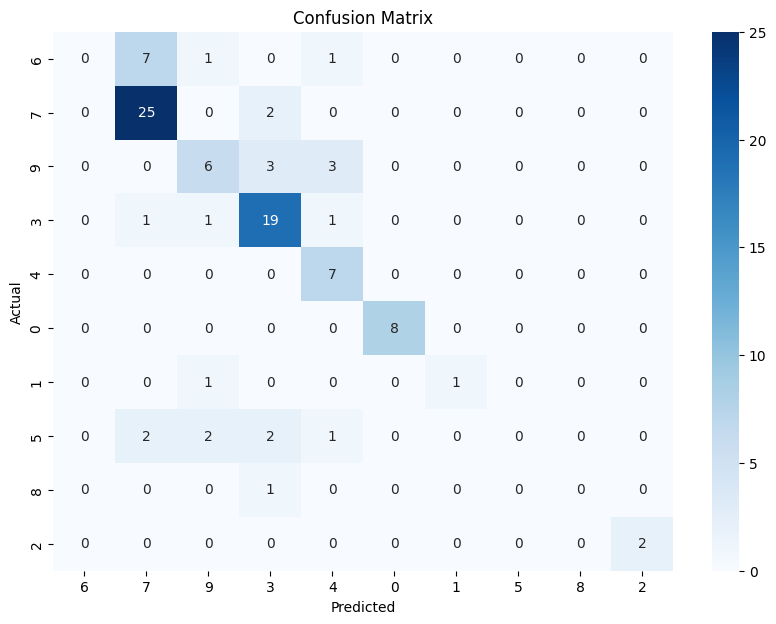

In [ ]:
unique_labels = pd.Series(y_test).unique()

# Calculate confusion matrix with specified labels
cm = confusion_matrix(y_test, preds, labels=unique_labels)

# Visualize confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

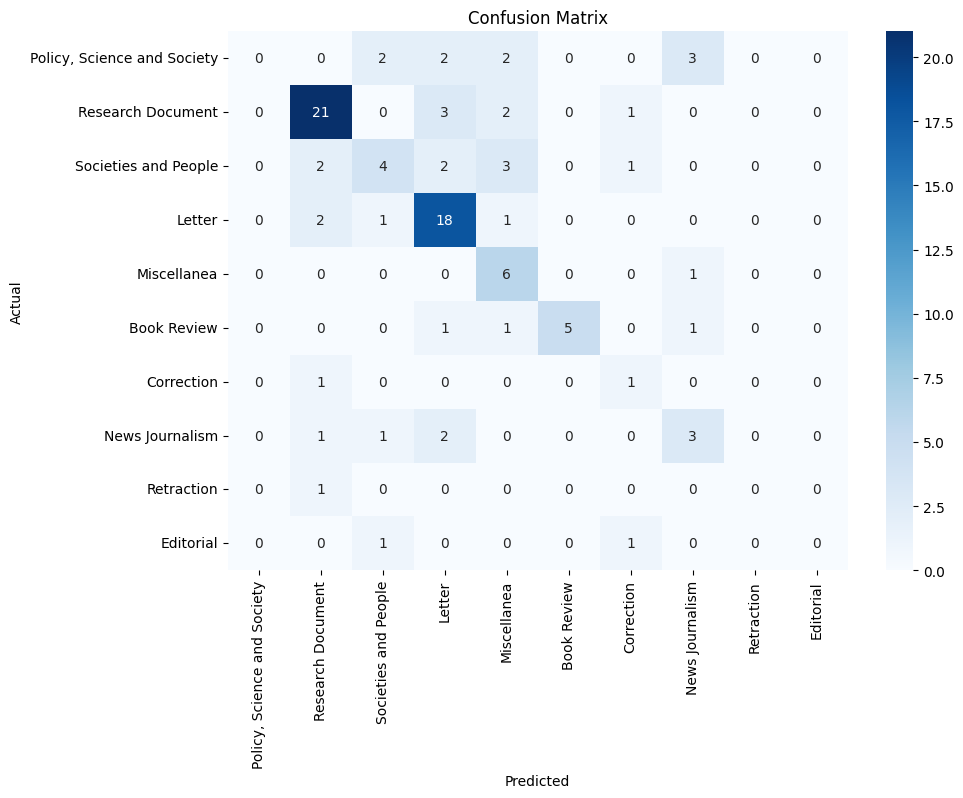

In [ ]:
unique_labels = df_test['Document_subtype'].unique()

# Calculate confusion matrix with specified labels
cm = confusion_matrix(df_test['Document_subtype'], preds, labels=unique_labels)

# Visualize confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Other

In [ ]:
import shutil
shutil.make_archive('model7', 'zip', 'model7')
from google.colab import files
files.download('model7.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shutil.make_archive('checkpoints', 'zip', 'checkpoints')
from google.colab import files
files.download('checkpoints.zip')

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
from setfit import SetFitModel

# Specify the path to your saved checkpoint
checkpoint_path = './checkpoint-876' # Replace with the actual path to your desired checkpoint

# Load the model from the checkpoint
loaded_model = SetFitModel.from_pretrained(checkpoint_path)
loaded_model2 = SetFitModel.from_pretrained('./FIRSTSAVE')
loaded_model3 = SetFitModel.from_pretrained("malteos/scincl")


In [ ]:
base_model = loaded_model.model_body
transformer = base_model._modules['0'].auto_model
embeddings = transformer.get_input_embeddings().weight
print(base_model)

In [ ]:
import numpy as np
doc = "The quick brown fox jumps over the lazy dog."
embedding = loaded_model.model_body.encode(doc)
embedding2 = loaded_model2.model_body.encode(doc)
embedding3 = loaded_model3.model_body.encode(doc)

print(np.dot(embedding2, embedding3)/(np.linalg.norm(embedding2)*np.linalg.norm(embedding3)))

In [ ]:
# Assuming 'loaded_model' is the name of your loaded SetFit model
# The specific layer names might vary depending on the model architecture
# You might need to inspect the model's structure to find the exact layer name

# Access the underlying Sentence Transformer model
sentence_transformer_model = loaded_model.model_body

# Access the layers of the Sentence Transformer model
# The last layer before the pooling or classification head is often the one containing the final embeddings
# You might need to adjust the index based on your specific model
# For example, if the last layer is a pooling layer, you'd look at the layer before it.
try:
    # This is a common way to access the last layer before the classification head
    # in models like those used by SetFit.
    penultimate_layer = sentence_transformer_model[1]
    print(sentence_transformer_model)

    # Access the weights of the layer
    # The way to access weights depends on the layer type (e.g., Linear, Dense)
    # If it's a Linear layer, you can typically access .weight
    print("Weights of the penultimate layer:")
    print(penultimate_layer)

except IndexError:
    print("Could not access the penultimate layer. The model might have a different structure.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
!cp -r ./model6 /content/drive/MyDrive/

In [3]:
!cp -r /content/drive/MyDrive/model6 ./

In [2]:
!cp -r /content/drive/MyDrive/data ./

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
